<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/EDA%20%26%20Feature%20Engineering/All_Feat_Word.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler



---

In [ ]:
# Read dataset
word_all_feat_df = pd.read_csv("/content/Word_All_features.csv")

# Exploratory Data Analysis (EDA)

In [ ]:
# Display the dataset dimensions (number of samples and features)
print("Shape:", word_all_feat_df.shape)

Shape: (20000, 44)


In [ ]:
# First rows
word_all_feat_df.head()

,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,...,path_a-accent1,path_a-sysClr,path_a-lt1,path_/a-accent4,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz,path_a-solidFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId,label
0,21,3,1,0,2,5.296863,0,0,223813,0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,1
1,0,0,0,1,0,7.415387,14,11,40156,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
2,0,0,0,1,0,7.595452,15,11,258403,0,...,NaN,NaN,NaN,NaN,2283.0,NaN,938.0,0.0,324.0,0
3,0,0,0,1,0,7.402378,14,11,39924,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
4,20,3,1,0,2,4.518811,0,0,199559,0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,1


- check for missing values in each feature
- missing value may affect the model performance so we need to preprocessing before training


In [ ]:
# Data types and missing values
word_all_feat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 44 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   ole_object_count                                                                20000 non-null  int64  
 1   ole_object_type_count                                                           20000 non-null  int64  
 2   macro_present                                                                   20000 non-null  int64  
 3   dde_present                                                                     20000 non-null  int64  
 4   vba_keywords_count                                                              20000 non-null  int64  
 5   entropy                                                                         20000 non-null  float64
 6   struct_Content

In [ ]:
# Analyze missing values by class.
# This helps determine whether missing values are random or
# class-dependent, which may indicate that the absence of a
# feature itself carries useful information.
word_all_feat_df.groupby("label").apply(lambda x: x.isnull().sum()).T

/tmp/ipykernel_518/2331955870.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  word_all_feat_df.groupby("label").apply(lambda x: x.isnull().sum()).T


label,0,1
ole_object_count,0,0
ole_object_type_count,0,0
macro_present,0,0
dde_present,0,0
vba_keywords_count,0,0
entropy,0,0
struct_ContentType,0,0
struct_PartName,0,0
file_size,0,0
struct_pos,0,0


- check for duplicate samples
- duplicate records may bias the model

In [ ]:
print("Duplicated rows:")
print(word_all_feat_df.duplicated().sum())

Duplicated rows:
3395


In [ ]:
duplicates = word_all_feat_df[word_all_feat_df.duplicated(keep=False)]
duplicates.head(20)

,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,...,path_a-accent1,path_a-sysClr,path_a-lt1,path_/a-accent4,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz,path_a-solidFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId,label
1,0,0,0,1,0,7.415387,14,11,40156,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
7,0,0,0,1,0,7.403323,14,11,40122,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
9,0,0,0,1,0,7.406928,14,11,40220,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
10,0,0,0,1,0,7.402384,14,11,38582,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
20,0,0,0,1,0,7.388109,14,11,36823,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
24,0,0,0,1,0,7.403409,14,11,39094,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
30,0,0,0,1,0,7.410483,14,11,40359,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
47,0,0,0,1,0,7.392260,14,11,37334,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
49,0,0,0,1,0,7.401797,14,11,39025,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
56,0,0,0,1,0,7.398320,14,11,37582,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0


In [ ]:
duplicates["label"].value_counts()

,count
label,
0,4558


all of duplicate record belong to label 0(Benign file)


In [ ]:
# Summary statistics for all numerical features
word_all_feat_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ole_object_count,20000.0,13.704600,14.383768,0.0,0.000000,5.500000,29.000000,1.000000e+02
ole_object_type_count,20000.0,1.498700,1.499170,0.0,0.000000,1.000000,3.000000,3.000000e+00
macro_present,20000.0,0.500150,0.500012,0.0,0.000000,1.000000,1.000000,1.000000e+00
dde_present,20000.0,0.499700,0.500012,0.0,0.000000,0.000000,1.000000,1.000000e+00
vba_keywords_count,20000.0,0.987200,1.010142,0.0,0.000000,0.000000,2.000000,6.000000e+00
entropy,20000.0,6.355623,1.039991,0.0,5.450493,6.116101,7.397829,7.677271e+00
struct_ContentType,20000.0,7.645050,6.397172,0.0,0.000000,4.000000,14.000000,3.000000e+01
struct_PartName,20000.0,5.803250,5.172454,0.0,0.000000,2.000000,11.000000,2.800000e+01
file_size,20000.0,135098.193150,731141.944154,0.0,38425.000000,130568.500000,197865.750000,5.959293e+07
struct_pos,20000.0,6.567700,4.577233,0.0,0.000000,9.000000,10.000000,1.100000e+01


### Summary of Descriptive Statistics

- The dataset is perfectly **balanced** between the two target classes.

- some features exhibit substantial right skewness and extreme maximum
values, particularly `file_size`, `path_w-r`, and `path_/w-p`. These
features require further outlier investigation.

- Multiple **structural** and **path-based** features show identical or nearly
identical descriptive statistics, suggesting possible redundancy.

Some features have almost the same value whenever they are present, but they are missing in only one class. This may mean the model is learning differences in how the dataset was created rather than learning real patterns of malicious files.


In [ ]:
# -------------------------------------------------------------------
# Feature Variability and Redundancy Check
# Count the number of unique values in each feature to identify
# constant, binary, low-cardinality, and potentially redundant features.
# -------------------------------------------------------------------

unique_counts = word_all_feat_df.nunique(dropna=True).sort_values()
unique_counts

,0
dde_present,2
macro_present,2
path_a-ln,2
path_/a-accent6,2
path_a-lt2,2
path_a-themeElements,2
path_a-accent3,2
path_a-hlink,2
struct_Extension,2
path_a-dk1,2


In [ ]:
# -------------------------------------------------------------------
# Detect exactly duplicated feature columns.
# Duplicate columns contain identical values across all samples and
# may introduce unnecessary redundancy into the feature set.
# -------------------------------------------------------------------

feature_df = word_all_feat_df.drop(columns=["label"])

duplicate_columns = []

for i, col1 in enumerate(feature_df.columns):
    for col2 in feature_df.columns[i + 1:]:
        if feature_df[col1].equals(feature_df[col2]):
            duplicate_columns.append((col1, col2))

print("Number of duplicated column pairs:", len(duplicate_columns))
display(duplicate_columns)

Number of duplicated column pairs: 62


[('path_w-r', 'path_/w-r'),
 ('path_a-hlink', 'path_a-accent3'),
 ('path_a-hlink', 'path_a-themeElements'),
 ('path_a-hlink', 'path_a-dk1'),
 ('path_a-hlink', 'path_/a-accent6'),
 ('path_a-hlink', 'path_a-lt2'),
 ('path_a-hlink', 'path_a-accent4'),
 ('path_a-hlink', 'path_/a-dk1'),
 ('path_a-hlink', 'path_a-accent1'),
 ('path_a-hlink', 'path_a-lt1'),
 ('path_a-hlink', 'path_/a-accent4'),
 ('path_a-accent3', 'path_a-themeElements'),
 ('path_a-accent3', 'path_a-dk1'),
 ('path_a-accent3', 'path_/a-accent6'),
 ('path_a-accent3', 'path_a-lt2'),
 ('path_a-accent3', 'path_a-accent4'),
 ('path_a-accent3', 'path_/a-dk1'),
 ('path_a-accent3', 'path_a-accent1'),
 ('path_a-accent3', 'path_a-lt1'),
 ('path_a-accent3', 'path_/a-accent4'),
 ('path_/a-effectLst', 'struct_dist'),
 ('path_/a-effectLst', 'path_a-alpha'),
 ('path_/a-effectLst', 'path_/a-outerShdw'),
 ('path_a-themeElements', 'path_a-dk1'),
 ('path_a-themeElements', 'path_/a-accent6'),
 ('path_a-themeElements', 'path_a-lt2'),
 ('path_a-the

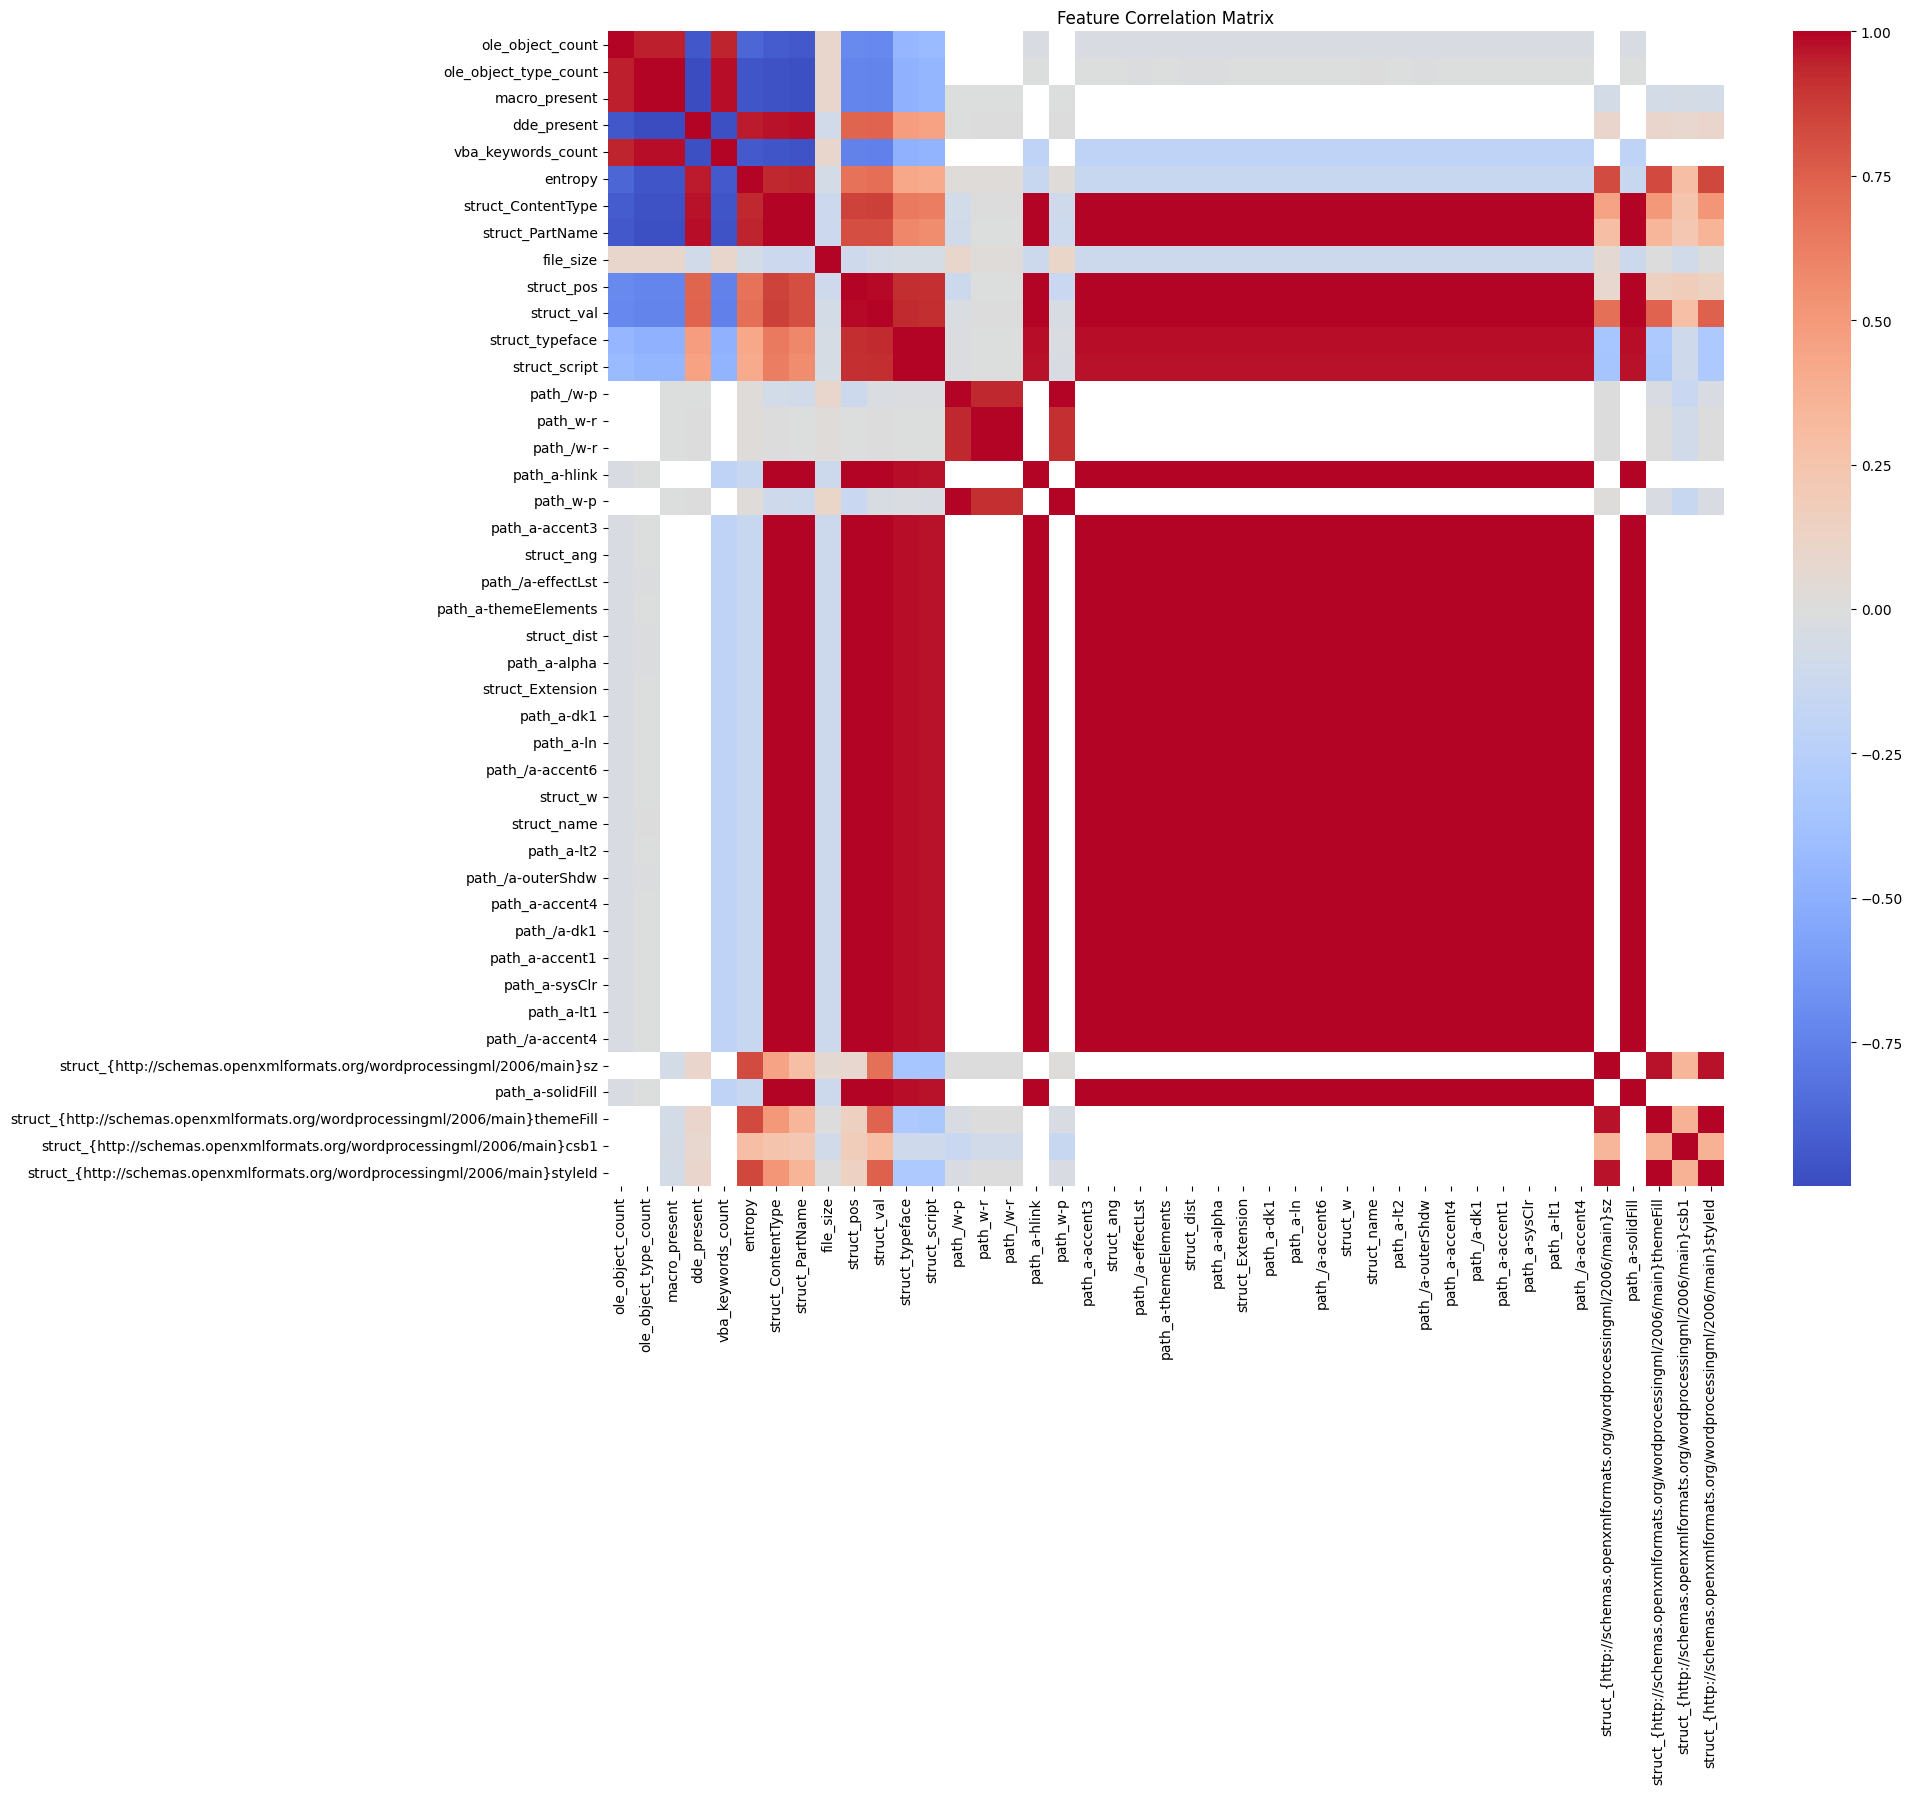

In [ ]:
# Compute the correlation matrix
corr = word_all_feat_df.drop(columns=["label"]).corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# -------------------------------------------------------------------
# List highly correlated feature pairs.
# This provides the exact correlation values instead of relying
# only on the visual heatmap.
# -------------------------------------------------------------------
corr_matrix = word_all_feat_df.drop(columns=["label"]).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

high_corr = high_corr[high_corr == 1]

high_corr

path_a-accent4        path_a-sysClr      1.0
path_/a-dk1           path_a-accent1     1.0
path_a-accent4        path_/a-accent4    1.0
                      path_a-lt1         1.0
path_/a-dk1           path_a-lt1         1.0
                                        ... 
path_a-themeElements  path_/a-accent6    1.0
path_a-accent1        path_a-lt1         1.0
                      path_a-sysClr      1.0
path_a-sysClr         path_a-lt1         1.0
path_a-accent1        path_/a-accent4    1.0
Length: 73, dtype: float64

### Correlation Analysis

Several feature pairs show very high positive correlations (≥ 0.90), indicating that they capture similar information.

Some feature pairs have a perfect correlation (1.00), confirming the presence of redundant features already identified during the duplicate feature analysis.

Highly correlated features will be retained in the baseline implementation. Their effect will be investigated during the feature selection stage.

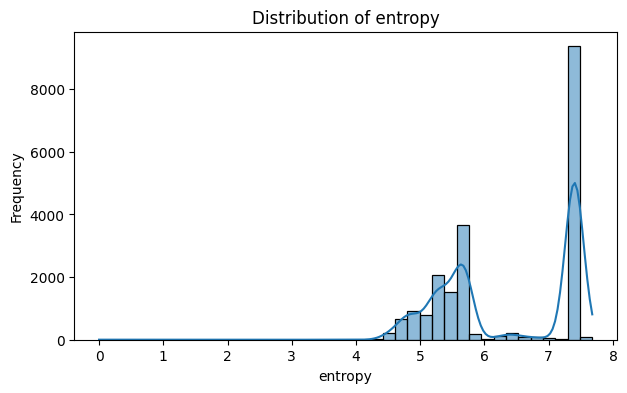

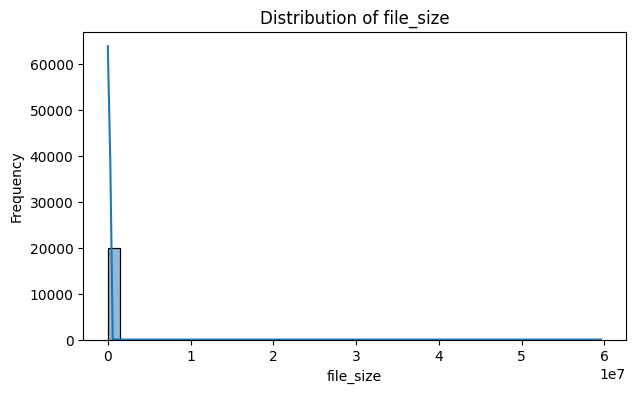

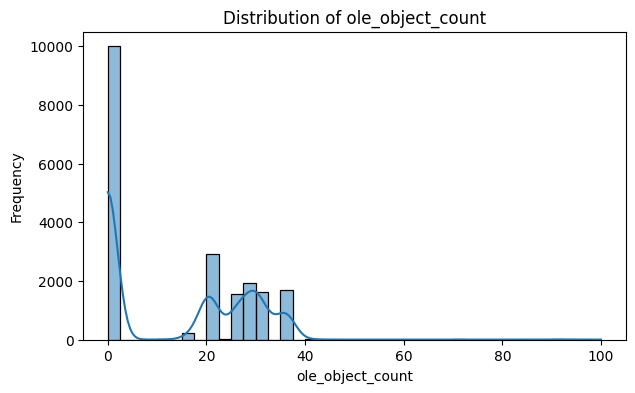

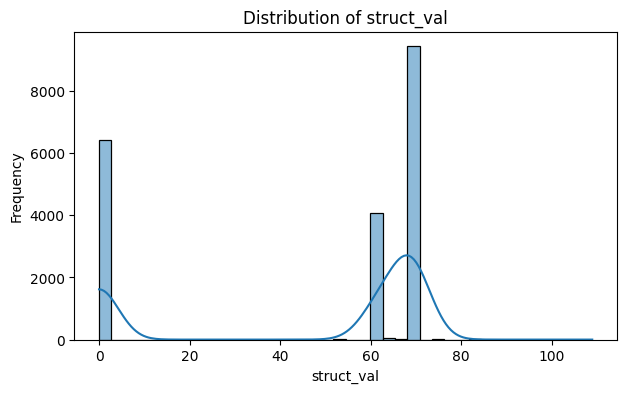

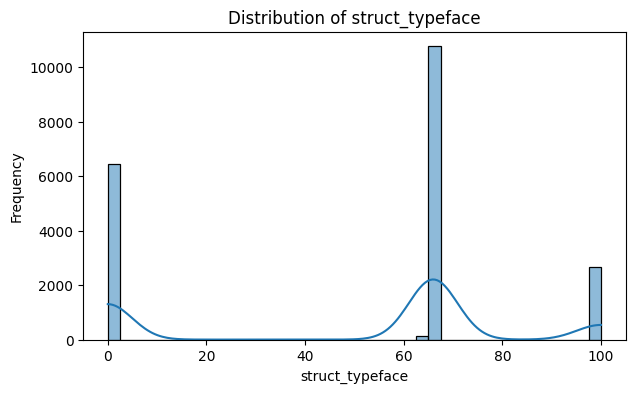

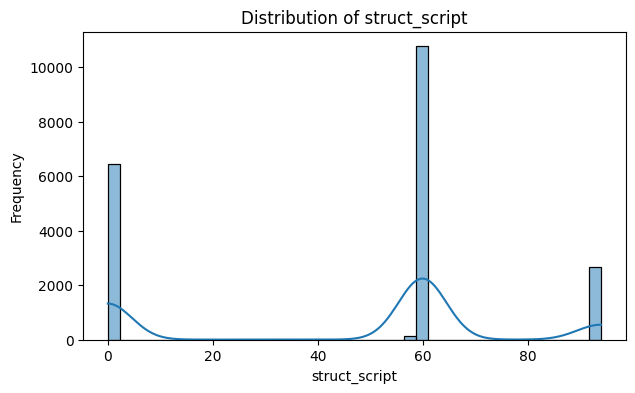

In [ ]:
features = [
    "entropy",
    "file_size",
    "ole_object_count",
    "struct_val",
    "struct_typeface",
    "struct_script"
]

for feature in features:

    plt.figure(figsize=(7,4))

    sns.histplot(
        word_all_feat_df[feature],
        bins=40,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

# Remove Duplicated Features

In [ ]:
clean_df = word_all_feat_df.drop_duplicates().reset_index(drop=True)
clean_df.shape

(16605, 44)

#Remove perfectly correlated features

In [ ]:
corr_matrix = clean_df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

columns_to_drop = [
    column for column in upper.columns
    if any(upper[column] == 1.0)
]

print("Columns to drop:", columns_to_drop)


clean_df = clean_df.drop(columns=columns_to_drop)
clean_df.shape

Columns to drop: ['path_/w-r', 'path_a-accent3', 'path_a-themeElements', 'struct_dist', 'path_a-alpha', 'path_a-dk1', 'path_/a-accent6', 'path_a-lt2', 'path_/a-outerShdw', 'path_a-accent4', 'path_/a-dk1', 'path_a-accent1', 'path_a-sysClr', 'path_a-lt1', 'path_/a-accent4']


(16605, 29)

# Convert null values

In [ ]:
clean_df.isnull().sum().sum()

np.int64(122840)

In [ ]:
# convert null values to zero
clean_df = clean_df.fillna(0)
clean_df.isnull().sum().sum()

np.int64(0)

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16605 entries, 0 to 16604
Data columns (total 29 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   ole_object_count                                                                16605 non-null  int64  
 1   ole_object_type_count                                                           16605 non-null  int64  
 2   macro_present                                                                   16605 non-null  int64  
 3   dde_present                                                                     16605 non-null  int64  
 4   vba_keywords_count                                                              16605 non-null  int64  
 5   entropy                                                                         16605 non-null  float64
 6   struct_Content

In [ ]:
# to detect columns with outlier
def find_skewed_columns(X, threshold=1.0):

    numeric_data = X.select_dtypes(include="number")


    skewness = numeric_data.skew().sort_values(
        key=abs,
        ascending=False
    )

    skewed_columns = skewness[skewness.abs() >= threshold]

    return skewed_columns

In [ ]:
skewed_columns = find_skewed_columns(
    clean_df,
    threshold=2.0
)

print(skewed_columns)

file_size    58.451072
path_w-r     52.564755
path_/w-p    43.512050
path_w-p     41.794485
dtype: float64


In [ ]:
#Feature Engineering
def calculate_embeded_content_features(clean_df):
  count = clean_df['ole_object_count']
  count_type = clean_df['ole_object_type_count']

  return np.where(count>0, count_type/count, 0)


def calculate_content_dinsity(clean_df):
  vba = clean_df['vba_keywords_count']
  sz = clean_df['file_size'] /1024
  return np.where(sz>0, vba/sz, 0)


clean_df['embeded_content_diversity'] = calculate_embeded_content_features(clean_df)
clean_df['active_content_dinsity'] = calculate_content_dinsity(clean_df)

In [ ]:
LOG_COLUMNS = {
    "file_size",
    "path_w-r",
    "path_w-p"
}

In [ ]:
BINARY_GROUPS = {
    "active_content_score": [
        "macro_present",
        "dde_present"
    ],
    "extrnel_reference_count": [
       "path_a-hlink"
    ]
}

In [ ]:
WORD_FEATURE_GROUPS = {

     "active_content_score": [
        "macro_present",
        "dde_present"
    ],

     "active_content_density":[
         'active_content_dinsity'
     ]


     ,
    "external_reference_count": [
       "path_a-hlink"
    ],

    "file size": [
        "file_size"
    ],

    "text_size": [
        "struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz"
    ],

    "embedded_objects": [
       'embeded_content_diversity',
       'ole_object_count',
        "struct_ContentType",
        "struct_PartName",
        "struct_Extension"
    ],


    "obfuscation_score": [
        "entropy"
    ],


    "struct_complexity_score": [
        "struct_pos",
        "struct_val",
        "struct_typeface",
        "struct_script",
        "struct_ang",
        "struct_w",
        "struct_name",
        "struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill",
        "struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1",
        "struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId",
        "path_w-p",
        "path_w-r",
        "path_/a-effectLst",
        "path_a-ln",
        "path_a-solidFill"

    ]

}

# Split the Data
This step must be taken before scaling to avoid data lackage

In [ ]:
X = clean_df.drop(columns=["label"])
y = clean_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**binary columns:**

1- sum

**count columns:**  

1- use log to handel outlier


2- Min-Max for norm (0.0 - 1.0)


3- Mean

In [ ]:
X_train_grouped = pd.DataFrame(index=X_train.index)
X_test_grouped = pd.DataFrame(index=X_test.index)

group_scalers = {}

In [ ]:
for group_name, columns in WORD_FEATURE_GROUPS.items():


    missing_columns = [
        col for col in columns
        if col not in X_train.columns
    ]

    if missing_columns:
        print(group_name, "missing:", missing_columns)
        continue


    train_values = X_train[columns].copy()
    test_values = X_test[columns].copy()


    scaler = MinMaxScaler()

    for col in group_name:
        if col in LOG_COLUMNS:
            X_train_grouped[col] = np.log1p(train_values[col].clip(lower=0))
            X_test_grouped[col] = np.log1p(test_values[col].clip(lower=0))


    if group_name in BINARY_GROUPS:

      if group_name == "active_content_score":
        X_train_grouped[group_name] = train_values.max(axis=1)
        X_test_grouped[group_name] = test_values.max(axis=1)

      else:
        X_train_grouped[group_name] = train_values
        X_test_grouped[group_name] = test_values


    else:
        train_scaled = scaler.fit_transform(train_values)
        test_scaled = scaler.transform(test_values)

        X_train_grouped[group_name] = train_scaled.mean(axis=1)
        X_test_grouped[group_name] = test_scaled.mean(axis=1)

    group_scalers[group_name] = scaler

In [ ]:
X_train_grouped.head()

,active_content_score,active_content_density,external_reference_count,file size,text_size,embedded_content,obfuscation_score,struct_complexity_score
1304,1,0.000000,0.0,0.000654,0.270337,0.171905,0.964094,0.358318
13982,1,0.098252,1.0,0.003003,0.000000,0.445952,0.600455,0.564688
9264,1,0.104683,0.0,0.002818,0.000000,0.168452,0.667345,0.000000
11668,1,0.000000,0.0,0.000662,0.270337,0.171905,0.964875,0.358374
2813,1,0.070828,0.0,0.004165,0.000000,0.178923,0.751608,0.000000


In [ ]:
print("Training shape:", X_train_grouped.shape)
print("Testing shape:", X_test_grouped.shape)

Training shape: (13284, 8)
Testing shape: (3321, 8)


In [ ]:
print("Number of groups:", len(WORD_FEATURE_GROUPS))

Number of groups: 8


# RandomForest

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_grouped, y_train)

y_pred = model.predict(X_test_grouped)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1321
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      3321
   macro avg       1.00      1.00      1.00      3321
weighted avg       1.00      1.00      1.00      3321



In [ ]:
results = []

for group_name in X_train_grouped.columns:

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        X_train_grouped[[group_name]],
        y_train
    )

    predictions = model.predict(
        X_test_grouped[[group_name]]
    )

    results.append({
        "group": group_name,
        "accuracy": accuracy_score(y_test, predictions),

        "precision": precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "f1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "f1",
    ascending=False
)

results_df

,group,accuracy,precision,recall,f1
7,struct_complexity_score,1.000000,1.000000,1.000000,1.000000
1,active_content_density,0.999699,0.999622,0.999750,0.999686
5,embedded_content,0.999699,0.999750,0.999621,0.999686
6,obfuscation_score,0.998494,0.998622,0.998236,0.998428
3,file size,0.996086,0.996236,0.995593,0.995912
4,text_size,0.985547,0.988281,0.981832,0.984819
2,external_reference_count,0.633544,0.760244,0.695750,0.623668
0,active_content_score,0.602228,0.301114,0.500000,0.375869


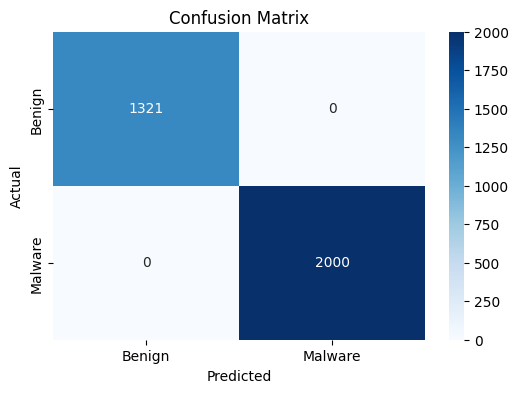

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malware'],
    yticklabels=['Benign', 'Malware']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()